Welcome back to the lab 2. From last week, you may have worked with mass spectrometry data and processed a bit of them by yourself. This lab will look into the results that you have made and we will practice a bit of data wrangling and visualization with Python. Thus, you can now understand the dataset much better with many more aspects from your result. As usual, please fill in your information here so we can give you some nice scores later. 


- Member1:
- Contact email: 

There will be ten questions and three bonus questions for you to answer. Please try to connect this exercise to the lectures from the first weeks. The main goal of this lab is that you are not afraid to work with mass spectrometry as it is amazing. Woo hoo. 


## Intended learning outcomes (ILOs) 

On completion of the lab, the student should be able to:
```
* demonstrate data-processing procedures in mass spectrometry proteomics
* demonstrate the ability to answer statistical questions with computational tools in mass spectrometry
* identify quality of high-throughput dataset and handle with statistical understandings
* identify relevant issues in technologies and data with accessible visualization techniques
```
## Let's start! 

You may recall from what we have done in the first lab. Now, we want to look at them properly. Let's start with some basic Python programming skill. So, please just copy the file and change the path below. (If you don't remember, just take it from your submission)

In [37]:
%config IPCompleter.greedy=True
%config InlineBackend.figure_format = 'retina'

In [38]:
# Install if it's your first time to run
!pip install pandas numpy matplotlib seaborn missingno

In [39]:
# Libraries ----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno


# File path of the result
# Fix when expor
result_path = 'diann_design_msstats_in.csv'
sdrf_path = '../lab1/sdrf/01_HELA_CERVIX_x_201T_LUNG.sdrf.tsv'
fasta_path = '../lab2/cancer_proteome_uniprot.fasta'

# Read the results
ms_result = pd.read_csv(result_path)
sdrf_data = pd.read_csv(sdrf_path, sep='\t')
# The FASTA file is not a tab-separated file; it's a plain text file in a special format.
# We'll read it line by line into a list:
with open(fasta_path, 'r') as f:
    fasta_data = f.readlines()


# Data overview
Let's check how do your data look. You can do it basically with any spreadsheet or texteditor software. Python is also one of them so don't be afraid. 

In [40]:
# Preview the results from DIANN

ms_result.head()


,ProteinName,PeptideSequence,PrecursorCharge,Intensity,Run,FragmentIon,ProductCharge,IsotopeLabelType,Condition,BioReplicate,Fraction
0,SHIP2_HUMAN,AAAEELLAR,2,2422.180,190115_9131_004HL_007L9_M06_S_1,NaN,0,L,CVCL_0030,3,1
1,SHIP2_HUMAN,AAAEELLAR,2,1871.680,190115_9131_004HL_007LQ_M04_S_1,NaN,0,L,CVCL_0030,1,1
2,SHIP2_HUMAN,AAAEELLAR,2,979.458,190116_9131_004IH_0082C_M06_S_1,NaN,0,L,CVCL_0030,2,1
3,SHIP2_HUMAN,AAAEELLAR,2,1597.820,190118_9131_004IH_00854_M04_S_1,NaN,0,L,CVCL_0030,6,1
4,SHIP2_HUMAN,AAAEELLAR,2,2712.280,190120_9131_004O3_0086J_M06_S_1,NaN,0,L,CVCL_0030,4,1


## Q1. 
**What do you see in the output file? What are the columns and the rows** 

Ans.

You can now see that it's difficult to see them clearly as there are many rows. It's hard to get an overview of the dataset. Let's dig a bit deeper and make it a little more organized. Let's now check numbers of samples. These should be related to what you have with the SDRF file previously. 

In [41]:
# Number of samples and what are they
(
    ms_result
    # Select column Reference and Condition
    [['Run', 'Condition', 'BioReplicate']]
    # Remove duplicated rows in the table
    .drop_duplicates()
    .sort_values(by=['Condition', 'Run', 'BioReplicate'])
)

,Run,Condition,BioReplicate
0,190115_9131_004HL_007L9_M06_S_1,CVCL_0030,3
1,190115_9131_004HL_007LQ_M04_S_1,CVCL_0030,1
2,190116_9131_004IH_0082C_M06_S_1,CVCL_0030,2
3,190118_9131_004IH_00854_M04_S_1,CVCL_0030,6
4,190120_9131_004O3_0086J_M06_S_1,CVCL_0030,4
5,190124_9131_004O3_0089Y_M04_S_1,CVCL_0030,5
12,191005_B43-T1-13_00DLF_00JCQ_M01_S_1,CVCL_X481,7
13,191006_B45-T1-13_00DMB_00JD7_M01_S_1,CVCL_X481,12
14,191008_B45-T2-13_00DMB_00JEP_M03_S_1,CVCL_X481,11
15,191008_B47-T1-13_00DN7_00JFO_M01_S_1,CVCL_X481,10


Does it look similar? Definitely, haha. 

Now, look at the proteins. 

## Q2. 
**Let's check the peptides and proteins. How many unique proteins and peptides? What percentage of matched protein from your library?**

In [42]:
# # 1. Find out unique protein from library

# # Peptides and Protein 
# # 2. Extract a table of three columns with unique proteins, peptides and precursor charge

# ms_result[[_, _, _]] \
#     .drop_duplicates()

In [43]:
# Delete! 

# Find rows in fasta_data list that start with '>'
rows_with_gt = [row for row in fasta_data if row.startswith('>')]
# Print out the number of rows that start with '>'
print("Number of rows starting with '>':", len(rows_with_gt))

# Extract unique proteins, peptides and precursor charges from ms_result
ms_result[['ProteinName', 'PeptideSequence', 'PrecursorCharge']] \
    .drop_duplicates()

Number of rows starting with '>': 1213


,ProteinName,PeptideSequence,PrecursorCharge
0,SHIP2_HUMAN,AAAEELLAR,2
6,TFR1_HUMAN,AAAEVAGQFVIK,2
18,FUMH_HUMAN,AAAEVNQDYGLDPK,2
30,ARI1B_HUMAN,AAAGSAAGGFQR,2
35,SND1_HUMAN,AAATQPDAKDTPDEPWAFPAR,3
...,...,...,...
48500,XPO1_HUMAN,YYGLQILENVIK,2
48512,GNA11_HUMAN,YYLTDVDR,2
48517,TOP1_HUMAN,YYNKVPVEKR,3
48526,PSB2_HUMAN,YYTPTISR,2


Ans.

## Q3. 
**What is the percentage of proteins that are being detected from the library?**

Ans. 


## BQ1. 
**Please show a summarised table containing numbers of protein counts and the detectable peptide numbers. For example, there are 10 proteins and each of them has 5 detectable peptides.**

In [44]:
# Delete! 

# Count unique proteins in ms_result
protein_count = ms_result['ProteinName'].nunique()
# Count unique peptides in ms_result
peptide_count = ms_result['PeptideSequence'].nunique()
# Calculate the percentage of proteins that are being detected from the library
protein_percentage = (protein_count / len(rows_with_gt)) * 100
print(f"Percentage of proteins that are being detected from the library: {protein_percentage:.2f}%")

Percentage of proteins that are being detected from the library: 44.27%


In [45]:
# Delete! 

# Peptide per protein count
# First, get unique ProteinName and PeptideSequence pairs
protein_peptide_unique = ms_result[['ProteinName', 'PeptideSequence']].drop_duplicates()

# Count unique peptides per protein
peptide_per_protein = protein_peptide_unique.groupby('ProteinName').size().reset_index(name='NumPeptides')

# Show a summary table: ProteinName and number of unique peptides detected
print(peptide_per_protein)

# Optionally, also show summary stats
print(f"\nTotal proteins detected: {peptide_per_protein.shape[0]}")
print(f"Average peptides per protein: {peptide_per_protein['NumPeptides'].mean():.2f}")


# Count NumPeptides
peptide_per_protein['NumPeptides'].value_counts()


     ProteinName  NumPeptides
0    1433E_HUMAN           20
1     2AAA_HUMAN           20
2     2ABA_HUMAN            6
3    3BHS1_HUMAN            1
4     5NTC_HUMAN            1
..           ...          ...
532    YES_HUMAN            2
533  ZMYM2_HUMAN            1
534  ZMYM3_HUMAN            1
535  ZN384_HUMAN            1
536  ZNF24_HUMAN            2

[537 rows x 2 columns]

Total proteins detected: 537
Average peptides per protein: 8.60


NumPeptides
1      175
2       65
3       42
4       37
6       33
8       17
5       17
9       12
7       10
14       9
10       9
12       8
11       8
15       7
13       7
16       7
39       6
20       5
22       5
21       5
31       3
19       3
17       3
27       3
37       3
18       3
41       2
29       2
25       2
24       2
56       2
23       2
26       2
38       2
73       1
102      1
34       1
36       1
44       1
76       1
70       1
80       1
47       1
150      1
78       1
50       1
114      1
35       1
33       1
48       1
43       1
71       1
30       1
Name: count, dtype: int64

In [46]:
# Peptide per protein count
# Hint: value_counts() or groupby().size()
# This will give you numbers of duplicated items in a particular column

# Dynamic range

Now, let's roughly look at the intensity of the peptides. We will use Python (matplotlib and seaborn) to visualize the data.

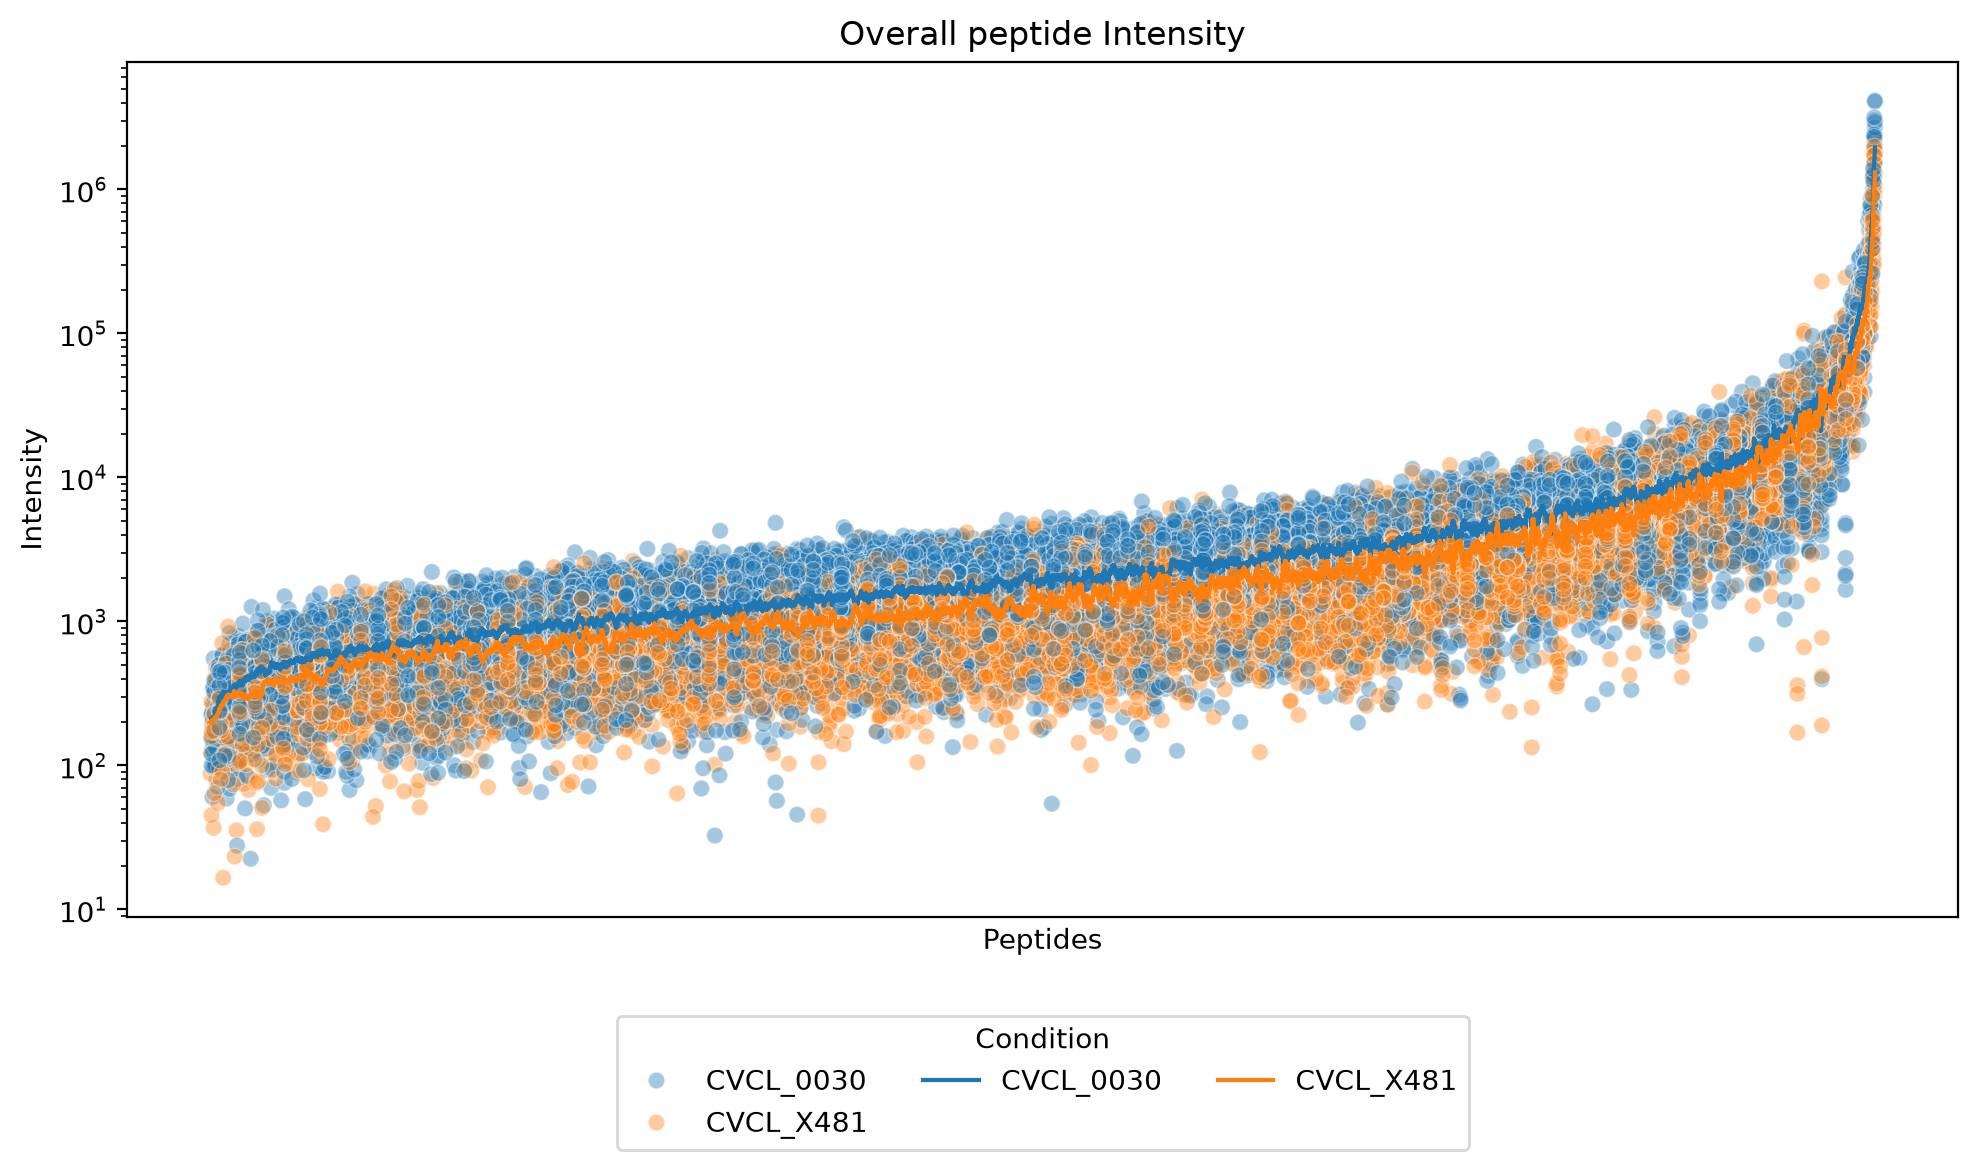

In [47]:
# Fix: Use column 'Condition' (or other valid values) instead of 'Reference' for coloring.

# Concatenate PeptideSequence and PrecursorCharge to new column
ms_result['PeptideSequencePC'] = (
    ms_result['PeptideSequence'] + '_' + ms_result['PrecursorCharge'].astype(str)
)

# Order peptide/precursors along the x-axis by their (mean) intensity
order = (
    ms_result.groupby('PeptideSequencePC')['Intensity']
    .mean()
    .sort_values()
    .index
)
x_pos = {name: i for i, name in enumerate(order)}
plot_df = ms_result.assign(x_pos=ms_result['PeptideSequencePC'].map(x_pos))

fig, ax = plt.subplots(figsize=(10, 6))

# plot all peptide/precursors, colored by Condition (since Reference does not exist)
sns.scatterplot(
    data=plot_df, x='x_pos', y='Intensity', hue='Condition', alpha=0.4, ax=ax
)

# rolling-mean trend line per Condition, as an approximation of geom_smooth()
for cond, group in plot_df.groupby('Condition'):
    group = group.sort_values('x_pos')
    trend = group['Intensity'].rolling(window=50, min_periods=1, center=True).mean()
    ax.plot(group['x_pos'], trend, label=cond)

ax.set_yscale('log')
ax.set_xticks([])
ax.set_xlabel('Peptides')
ax.set_ylabel('Intensity')
ax.set_title('Overall peptide Intensity')
ax.legend(title='Condition', loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3)

plt.tight_layout()
plt.show()

You now can see the dynamic range of every peptides that were detected. The intensity of the peptides is quite different maybe in some samples.

## Q4. 
**What can we imply from this plot? What is the dynamic range of the dataset?**

Ans.

## Q5. 
**Pick one protein that is comprised of 10 detectable peptides. Visualize the peptide intensity. Do we see every peptide in every sample? Does every peptide have the same intensity in each sample for each peptide. If not, why?**

In [48]:
# Select a protein with 10 peptides that are detected in every sample

# Print out the protein name


# Visualize it

     ProteinName  NumPeptides
31   APEX1_HUMAN           10
64   CADH2_HUMAN           10
185  GSTO1_HUMAN           10
186  GSTP1_HUMAN           10
284    MET_HUMAN           10
299   MSH6_HUMAN           10
431   SDHB_HUMAN           10
454  SMCE1_HUMAN           10
482  TCEA1_HUMAN           10
I select this protein: TCEA1_HUMAN


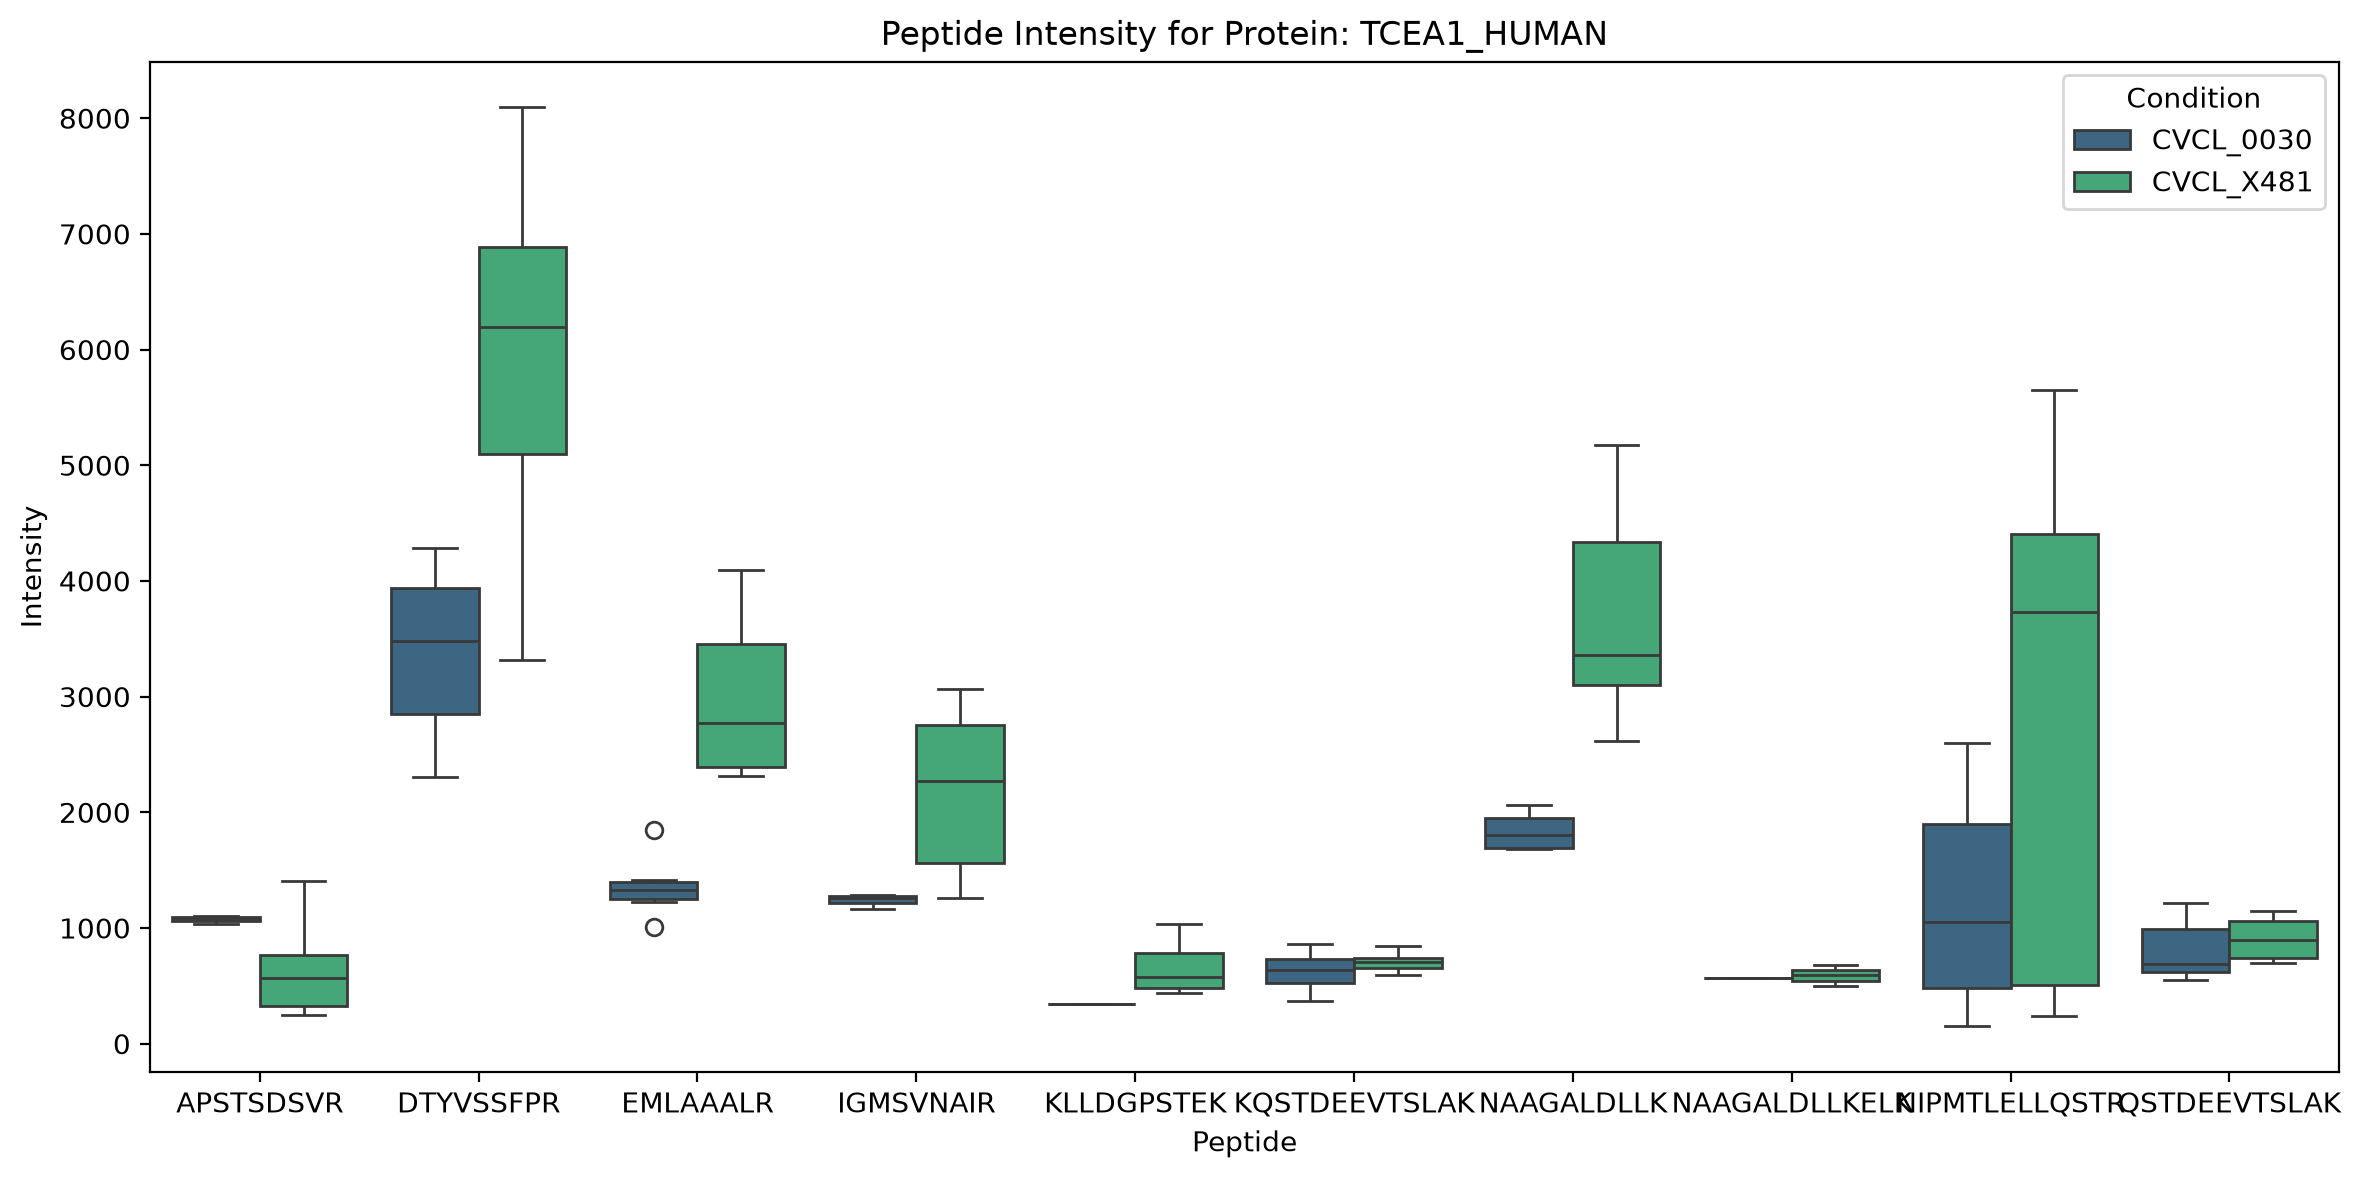

In [49]:
# Delete! 

protein_10pep = peptide_per_protein[peptide_per_protein['NumPeptides'] == 10]
print(protein_10pep)

# Select the last ProteinName and Print it
protein_name_10pep = protein_10pep.iloc[-1]['ProteinName']
print(f"I select this protein: {protein_name_10pep}")

# Visualize it
protein_10pep_data = ms_result[ms_result['ProteinName'] == protein_name_10pep]

# Plot: x axis is peptide, box plot with colors by Condition
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=protein_10pep_data,
    x='PeptideSequence',
    y='Intensity',
    hue='Condition',
    palette='viridis'
)
plt.xlabel('Peptide')
plt.ylabel('Intensity')
plt.title(f'Peptide Intensity for Protein: {protein_name_10pep}')
plt.legend(title='Condition')
plt.tight_layout()
plt.show()


Ans.

# Missing data 
Let's now visualize the data that you already have with their intensities. We will look the data at the peptide precursor level. 

Run                                              190115_9131_004HL_007L9_M06_S_1  \
ProteinName PeptideSequence     PrecursorCharge                                    
1433E_HUMAN AAFDDAIAELDTLSEESYK 2                                        2398.47   
                                3                                        2656.83   
            DSTLIMQLLR          2                                        4645.35   
            EAAENSLVAYK         2                                       13571.80   
            EALQDVEDENQ         2                                        1358.31   

Run                                              190115_9131_004HL_007LQ_M04_S_1  \
ProteinName PeptideSequence     PrecursorCharge                                    
1433E_HUMAN AAFDDAIAELDTLSEESYK 2                                       1113.550   
                                3                                       1136.230   
            DSTLIMQLLR          2                                       256

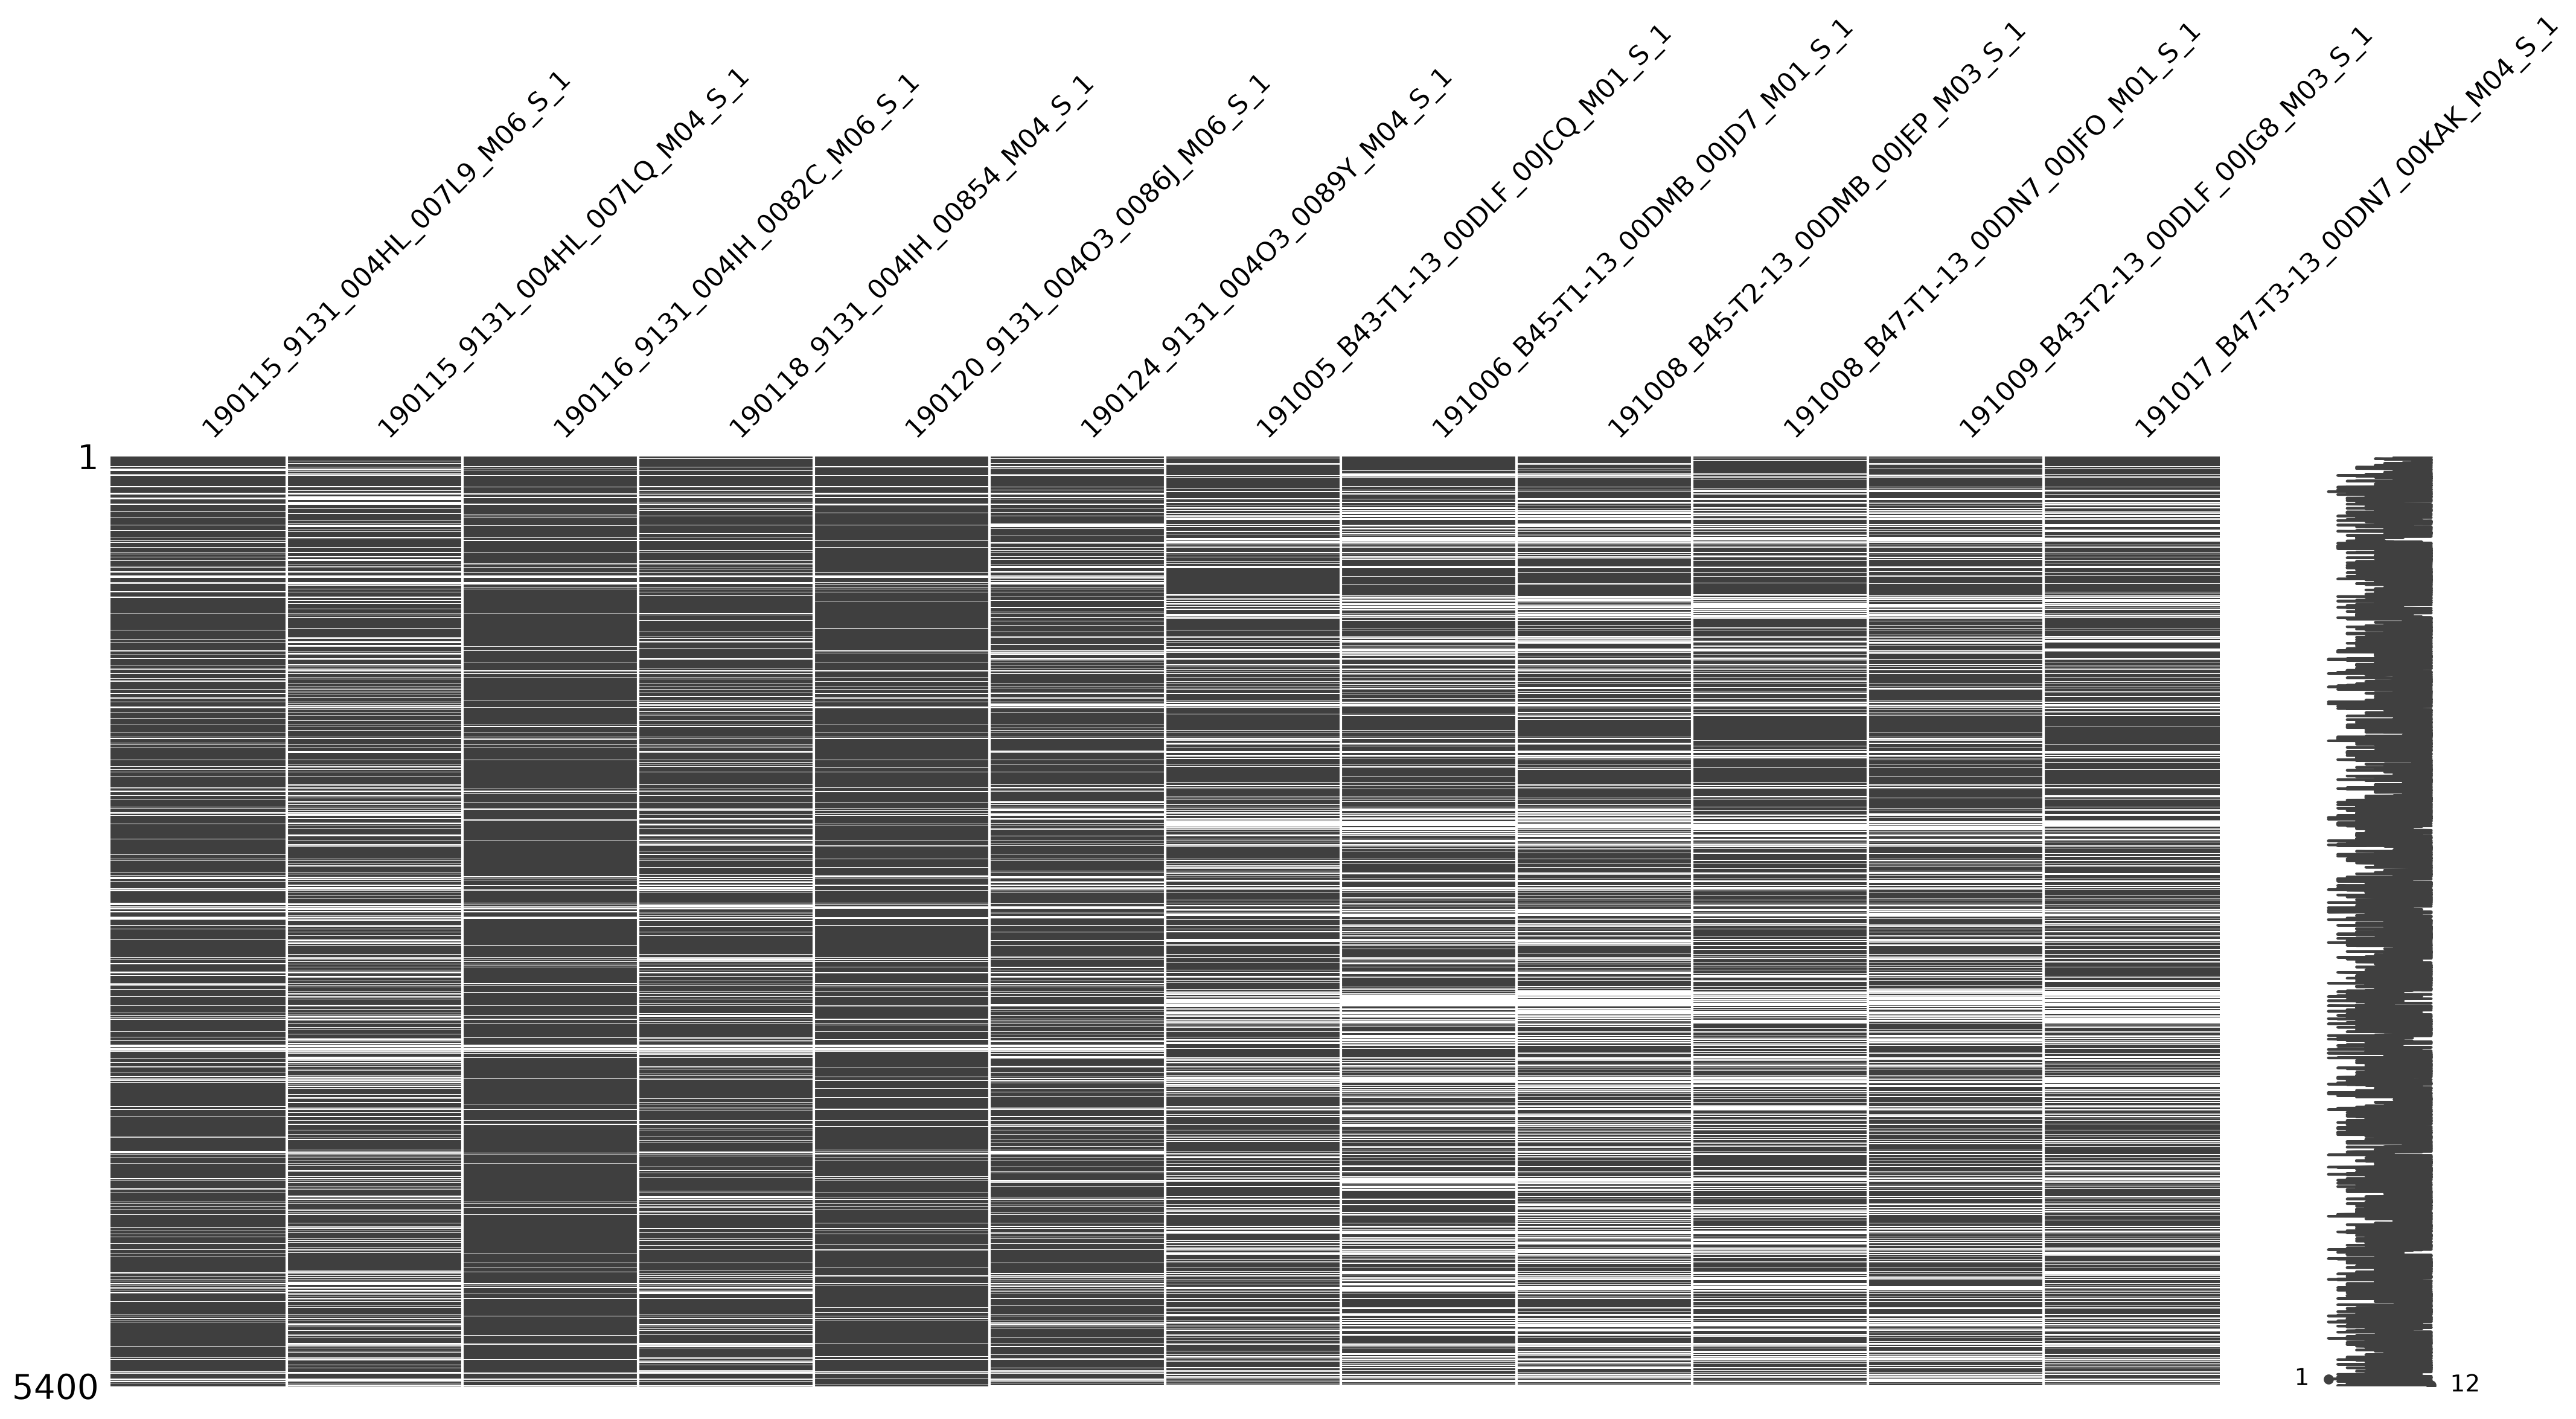

In [50]:
# Create a peptide x run intensity matrix
select_pept = ms_result[['ProteinName', 'Run', 'PeptideSequence', 'PrecursorCharge', 'Intensity']].pivot_table(
    index=['ProteinName', 'PeptideSequence', 'PrecursorCharge'],
    columns='Run',
    values='Intensity'
)

# Print the first 5 rows of select_pept
print(select_pept.head())

msno.matrix(select_pept)
plt.show()

The problem now is that we can detect some missing data in the dataset. This is a common problem in mass spectrometry data. We can see that some peptides are not detected in some samples. 


## Q6. 
**Why there are missing values with MS?**


Ans. 


Let's now select good quality peptide based on the missing data. We will remove the peptides that are not detected in more than 50% of the samples.

## Q7. 
**From `select_pept` table, remove the peptides that are not detected in more than 50% of the samples. How many unique proteins and peptides are left?**

In [51]:
# For each peptide row, calculate the percentage of non-NaN values across runs (samples)
non_nan_fraction = select_pept.notna().sum(axis=1) / select_pept.shape[1] * 100
display(non_nan_fraction.head())


# Select filtered peptides 


# Protein count


# Peptide count

ProteinName  PeptideSequence      PrecursorCharge
1433E_HUMAN  AAFDDAIAELDTLSEESYK  2                  100.000000
                                  3                  100.000000
             DSTLIMQLLR           2                  100.000000
             EAAENSLVAYK          2                  100.000000
             EALQDVEDENQ          2                   66.666667
dtype: float64

In [52]:
# For each peptide row, calculate the percentage of non-NaN values across runs (samples)
non_nan_fraction = select_pept.notna().sum(axis=1) / select_pept.shape[1] * 100
display(non_nan_fraction.head())

# DataFrame of peptides/charge that have more than 50% non-NaN values
filter_pept = select_pept[non_nan_fraction > 50]

# Print the first 5 rows of the filtered peptides
display(filter_pept.head())

# Get MultiIndex levels as columns for filtering and counting
filter_pept_reset = filter_pept.reset_index()

# How many unique proteins and peptides are left?
print(f"Number of unique proteins: {filter_pept_reset['ProteinName'].nunique()}")
print(f"Number of unique peptides: {filter_pept_reset['PeptideSequence'].nunique()}")


ProteinName  PeptideSequence      PrecursorCharge
1433E_HUMAN  AAFDDAIAELDTLSEESYK  2                  100.000000
                                  3                  100.000000
             DSTLIMQLLR           2                  100.000000
             EAAENSLVAYK          2                  100.000000
             EALQDVEDENQ          2                   66.666667
dtype: float64

Run                                              190115_9131_004HL_007L9_M06_S_1  \
ProteinName PeptideSequence     PrecursorCharge                                    
1433E_HUMAN AAFDDAIAELDTLSEESYK 2                                        2398.47   
                                3                                        2656.83   
            DSTLIMQLLR          2                                        4645.35   
            EAAENSLVAYK         2                                       13571.80   
            EALQDVEDENQ         2                                        1358.31   

Run                                              190115_9131_004HL_007LQ_M04_S_1  \
ProteinName PeptideSequence     PrecursorCharge                                    
1433E_HUMAN AAFDDAIAELDTLSEESYK 2                                       1113.550   
                                3                                       1136.230   
            DSTLIMQLLR          2                                       2562.370   
            EAAENSLVAYK         2                                      13422.600   
            EALQDVEDENQ         2                                        948.895   

Run                                              190116_9131_004IH_0082C_M06_S_1  \
ProteinName PeptideSequence     PrecursorCharge                                    
1433E_HUMAN AAFDDAIAELDTLSEESYK 2                                        3075.28   
                                3                                        3915.55   
            DSTLIMQLLR          2                                        8612.41   
            EAAENSLVAYK         2                                       16297.60   
            EALQDVEDENQ         2                                        1082.64   

Run                                              190118_9131_004IH_00854_M04_S_1  \
ProteinName PeptideSequence     PrecursorCharge                                    
1433E_HUMAN AAFDDAIAELDTLSEESYK 2                                        545.222   
                                3                                        899.134   
            DSTLIMQLLR          2                                       3031.030   
            EAAENSLVAYK         2                                      14785.700   
            EALQDVEDENQ         2                                        922.285   

Run                                              190120_9131_004O3_0086J_M06_S_1  \
ProteinName PeptideSequence     PrecursorCharge                                    
1433E_HUMAN AAFDDAIAELDTLSEESYK 2                                        2643.79   
                                3                                        2934.18   
            DSTLIMQLLR          2                                        5645.53   
            EAAENSLVAYK         2                                       24572.80   
            EALQDVEDENQ         2                                        1952.79   

Run                                              190124_9131_004O3_0089Y_M04_S_1  \
ProteinName PeptideSequence     PrecursorCharge                                    
1433E_HUMAN AAFDDAIAELDTLSEESYK 2                                        949.824   
                                3                                       1260.530   
            DSTLIMQLLR          2                                       2431.910   
            EAAENSLVAYK         2                                      17980.500   
            EALQDVEDENQ         2                                       1132.830   

Run                                              191005_B43-T1-13_00DLF_00JCQ_M01_S_1  \
ProteinName PeptideSequence     PrecursorCharge                                         
1433E_HUMAN AAFDDAIAELDTLSEESYK 2                                             1855.40   
                                3                                             1815.88   
            DSTLIMQLLR          2                                             9996.58   
            EAAENSLVA

Number of unique proteins: 426
Number of unique peptides: 3456


Looks like we are more confident with the data now. Let's now calculate the protein abundance. The rule is we expect all peptide precursors to be detected with similar intensity in every protein. Meaning that, we can average the intensity of the peptides in each protein and compare them with the rest.

## Q8.
**What are the protein abundances in each sample?**

In [53]:
# Hint: groupby() and .mean()

In [54]:
# Delete! 
# Calculate protein abundance in each sample:
# For each protein (ProteinName), take the mean intensity across all its peptides for each run (sample).
# This gives a DataFrame with ProteinName as index, columns as runs, values as mean intensities (protein abundance).

# Compute abundance by averaging across peptides for each protein in every run.
prot_level = filter_pept.groupby(['ProteinName']).mean()

# Show a summary: shape and preview
print("Protein abundance table shape:", prot_level.shape)
display(prot_level.head(20))

Protein abundance table shape: (426, 12)


Run,190115_9131_004HL_007L9_M06_S_1,190115_9131_004HL_007LQ_M04_S_1,190116_9131_004IH_0082C_M06_S_1,190118_9131_004IH_00854_M04_S_1,190120_9131_004O3_0086J_M06_S_1,190124_9131_004O3_0089Y_M04_S_1,191005_B43-T1-13_00DLF_00JCQ_M01_S_1,191006_B45-T1-13_00DMB_00JD7_M01_S_1,191008_B45-T2-13_00DMB_00JEP_M03_S_1,191008_B47-T1-13_00DN7_00JFO_M01_S_1,191009_B43-T2-13_00DLF_00JG8_M03_S_1,191017_B47-T3-13_00DN7_00KAK_M04_S_1
ProteinName,,,,,,,,,,,,
1433E_HUMAN,14724.792435,10884.285000,12915.071875,10986.681524,19642.250083,11840.982000,20897.441900,16633.675600,9823.043632,13984.119650,14279.650176,13926.867579
2AAA_HUMAN,3506.325000,3189.231105,3926.611652,3059.244273,5151.632478,3706.946905,3620.329095,2392.527286,1722.972476,3111.252000,2638.328400,2974.268826
2ABA_HUMAN,2248.986000,1391.984400,1802.140000,1831.335800,3087.828000,1942.770400,353.499000,769.856750,457.603500,704.129000,352.862000,686.135667
3BHS1_HUMAN,3052.470000,3277.190000,3045.950000,3978.400000,5439.500000,6132.760000,52944.300000,49485.700000,35037.100000,53968.900000,45232.200000,55913.900000
5NTC_HUMAN,8479.760000,NaN,7489.710000,NaN,5889.390000,6381.730000,3762.910000,NaN,4210.840000,1296.430000,NaN,1703.590000
5NTD_HUMAN,1653.385000,1210.469750,1104.558000,1002.493000,1317.442667,1378.040000,2107.338167,1299.631000,1135.745600,1416.655833,1460.846333,1119.132000
AAMP_HUMAN,1640.220000,2134.689000,2031.488500,1278.946500,3689.040000,972.172000,1882.850000,1530.460000,863.167000,1438.810000,1222.250000,1816.790000
ABI1_HUMAN,1096.855000,948.485500,1108.707667,810.758500,1800.926667,206.254000,1364.536333,1248.540000,706.448000,1255.685000,1090.182500,1085.460000
ACACA_HUMAN,1714.064000,1037.404667,1727.938818,1320.784857,2550.637143,1614.023462,2109.015846,1697.183375,1073.803000,1902.234154,1511.815462,2043.534786


# Protein abundance
## Q9.
**Let's plot a dynamic range of protein concentration in each sample. What can we imply from this plot?**

In [55]:
sdrf_data.head()

,source name,characteristics[model_id],characteristics[Project_Identifier],characteristics[BROAD_ID],characteristics[CCLE_ID],characteristics[Date],characteristics[cell type],characteristics[Accession],characteristics[organism part],characteristics[Site],...,comment[fraction identifier],comment[technical replicate],comment[instrument],comment[cleavage agent details],comment[modification parameters],comment[precursor mass tolerance],comment[fragment mass tolerance],comment[MS1 scan range],comment[MS2 scan range],factor value[Accession]
0,PXD030304_101,SIDM00846,SIDM00846;HeLa,ACH-001086,HELA_CERVIX,2019-01-15,HeLa,CVCL_0030,Uterine cervix,"Uterus, cervix",...,1,1,NT=TripleTOF 6600;AC=MS:1002533,AC=MS:1001251;NT=Trypsin,NT=Carbamidomethyl;AC=UNIMOD:4;TA=C;MT=Fixed,40 ppm,40 ppm,400m/z-1250m/z,100m/z-2000m/z,CVCL_0030
1,PXD030304_102,SIDM00846,SIDM00846;HeLa,ACH-001086,HELA_CERVIX,2019-01-16,HeLa,CVCL_0030,Uterine cervix,"Uterus, cervix",...,1,2,NT=TripleTOF 6600;AC=MS:1002533,AC=MS:1001251;NT=Trypsin,NT=Carbamidomethyl;AC=UNIMOD:4;TA=C;MT=Fixed,40 ppm,40 ppm,400m/z-1250m/z,100m/z-2000m/z,CVCL_0030
2,PXD030304_103,SIDM00846,SIDM00846;HeLa,ACH-001086,HELA_CERVIX,2019-01-15,HeLa,CVCL_0030,Uterine cervix,"Uterus, cervix",...,1,3,NT=TripleTOF 6600;AC=MS:1002533,AC=MS:1001251;NT=Trypsin,NT=Carbamidomethyl;AC=UNIMOD:4;TA=C;MT=Fixed,40 ppm,40 ppm,400m/z-1250m/z,100m/z-2000m/z,CVCL_0030
3,PXD030304_104,SIDM00846,SIDM00846;HeLa,ACH-001086,HELA_CERVIX,2019-01-20,HeLa,CVCL_0030,Uterine cervix,"Uterus, cervix",...,1,4,NT=TripleTOF 6600;AC=MS:1002533,AC=MS:1001251;NT=Trypsin,NT=Carbamidomethyl;AC=UNIMOD:4;TA=C;MT=Fixed,40 ppm,40 ppm,400m/z-1250m/z,100m/z-2000m/z,CVCL_0030
4,PXD030304_105,SIDM00846,SIDM00846;HeLa,ACH-001086,HELA_CERVIX,2019-01-24,HeLa,CVCL_0030,Uterine cervix,"Uterus, cervix",...,1,5,NT=TripleTOF 6600;AC=MS:1002533,AC=MS:1001251;NT=Trypsin,NT=Carbamidomethyl;AC=UNIMOD:4;TA=C;MT=Fixed,40 ppm,40 ppm,400m/z-1250m/z,100m/z-2000m/z,CVCL_0030


In [56]:
# Melt and join with sdrf by RUN
# We want to "melt" the DataFrame so that each row is a protein, run, and abundance,
# and then join with sdrf so that each row also includes Condition, BioReplicate, etc.

# Reset index so that ProteinName is a column
prot_level_reset = prot_level.reset_index()

# Melt from wide to long: columns that are runs to one column "Run" and one column "Abundance"
prot_level_long = prot_level_reset.melt(id_vars=["ProteinName"], var_name="Run", value_name="Abundance")

# --- Fix: Join with SDRF, match columns present in SDRF as index (KeyError fix) ---

# Prepare SDRF copy and ensure correct columns for merging
sdrf_fix = sdrf_data.copy()
sdrf_fix['Run'] = sdrf_fix['comment[data file]'].str.replace(r'\.mzML$', '', regex=True)
sdrf_fix['Condition'] = sdrf_fix['characteristics[cell type]']

# Select Run, Condition, and any other columns you need
merge_cols = ['Run', 'Condition']
# Select only the needed columns from SDRF for merging
sdrf_merge = sdrf_fix[merge_cols].drop_duplicates()

# Merge on Run to bring in all sample information (Condition, BioReplicate, etc)
prot_abund = prot_level_long.merge(
    sdrf_merge, on="Run", how="left"
)

# Display head of the merged DataFrame (joined: abundance + metadata)
display(prot_abund.head())

,ProteinName,Run,Abundance,Condition
0,1433E_HUMAN,190115_9131_004HL_007L9_M06_S_1,14724.792435,HeLa
1,2AAA_HUMAN,190115_9131_004HL_007L9_M06_S_1,3506.325000,HeLa
2,2ABA_HUMAN,190115_9131_004HL_007L9_M06_S_1,2248.986000,HeLa
3,3BHS1_HUMAN,190115_9131_004HL_007L9_M06_S_1,3052.470000,HeLa
4,5NTC_HUMAN,190115_9131_004HL_007L9_M06_S_1,8479.760000,HeLa


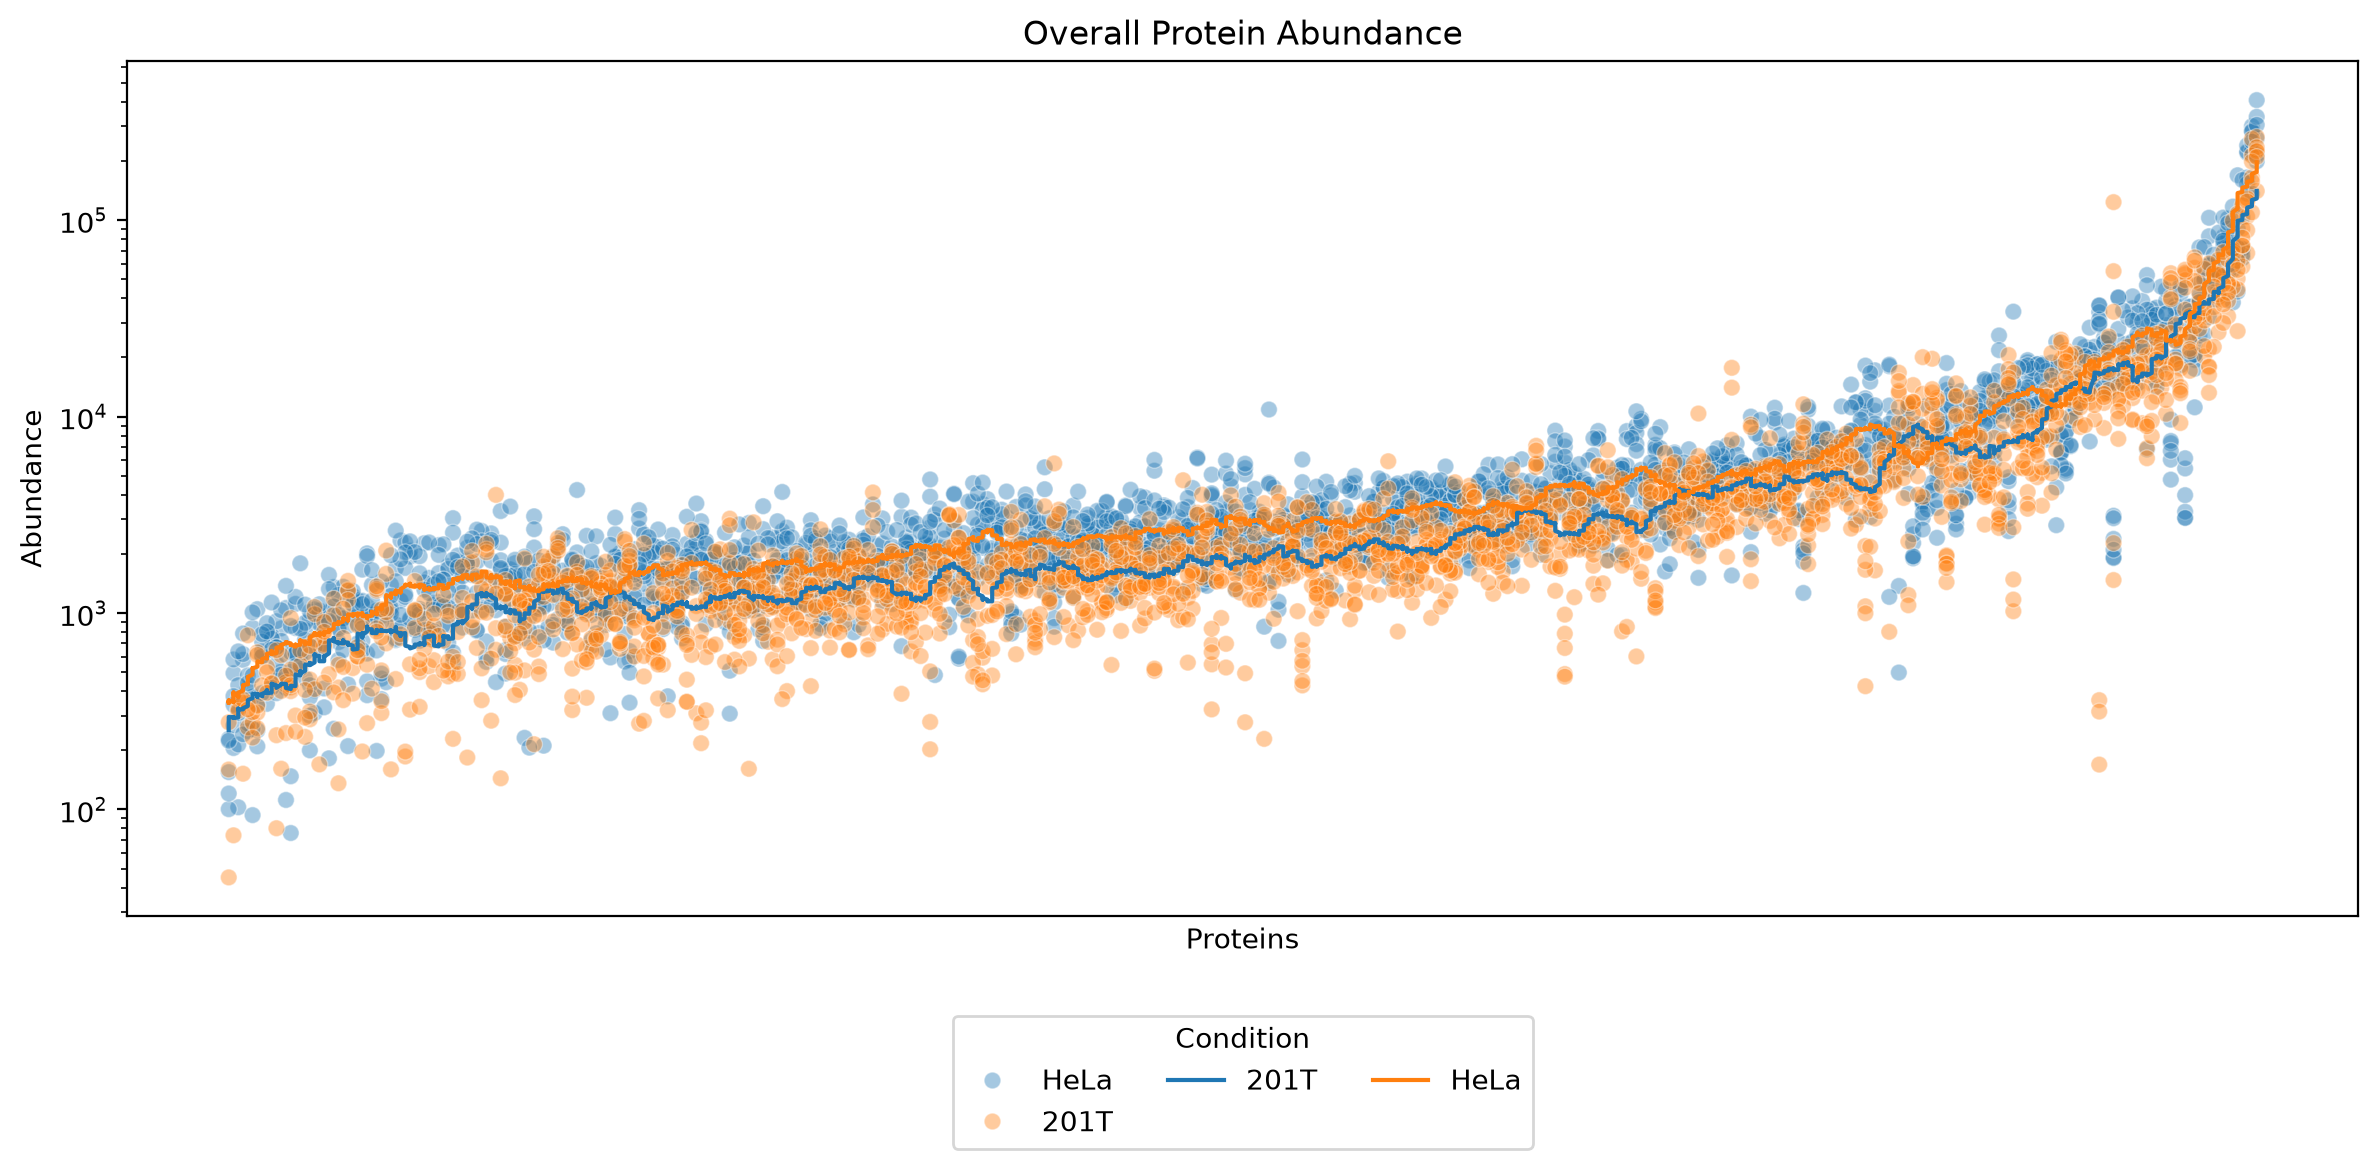

In [57]:
# Similar plotting style to earlier (see cell with @file_context_0), with trend lines per condition and improved layout

fig, ax = plt.subplots(figsize=(12, 6))

# Compute ordering: sort proteins by total abundance for visualization, optional: use median or sum
protein_order = (
    prot_abund.groupby('ProteinName')['Abundance']
    .sum()
    .sort_values()
    .index
)

# Assign x position based on ordering for scatter plot (geom_smooth-style trend lines possible)
protein_pos = {prot: i for i, prot in enumerate(protein_order)}
plot_df = prot_abund.copy()
plot_df['x_pos'] = plot_df['ProteinName'].map(protein_pos)

# Scatter: all proteins/abundances, colored by Condition
sns.scatterplot(
    data=plot_df, x='x_pos', y='Abundance', hue='Condition', alpha=0.4, ax=ax
)

# Rolling-mean trend per Condition, like geom_smooth()
for cond, group in plot_df.groupby('Condition'):
    group = group.sort_values('x_pos')
    trend = group['Abundance'].rolling(window=50, min_periods=1, center=True).mean()
    ax.plot(group['x_pos'], trend, label=cond)

ax.set_yscale('log')
ax.set_xticks([])  # No individual protein names, too many
ax.set_xlabel('Proteins')
ax.set_ylabel('Abundance')
ax.set_title('Overall Protein Abundance')
ax.legend(title='Condition', loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3)

plt.tight_layout()
plt.show()

## Q10. 
**Visualize the abundance of protein from TP53 gene with boxplot. What can we summarise here? Additionally, if it is in your experiment, how would you proceed?**

In [ ]:
# hint
# Fix this code below

# Select Protein
prot = (
    prot_level
    .merge(ms_result[['Reference', 'Condition']].drop_duplicates(), on='Reference')
    [[__, _, __]]
    .query("ProteinName == '____'")
)


# # Boxplot

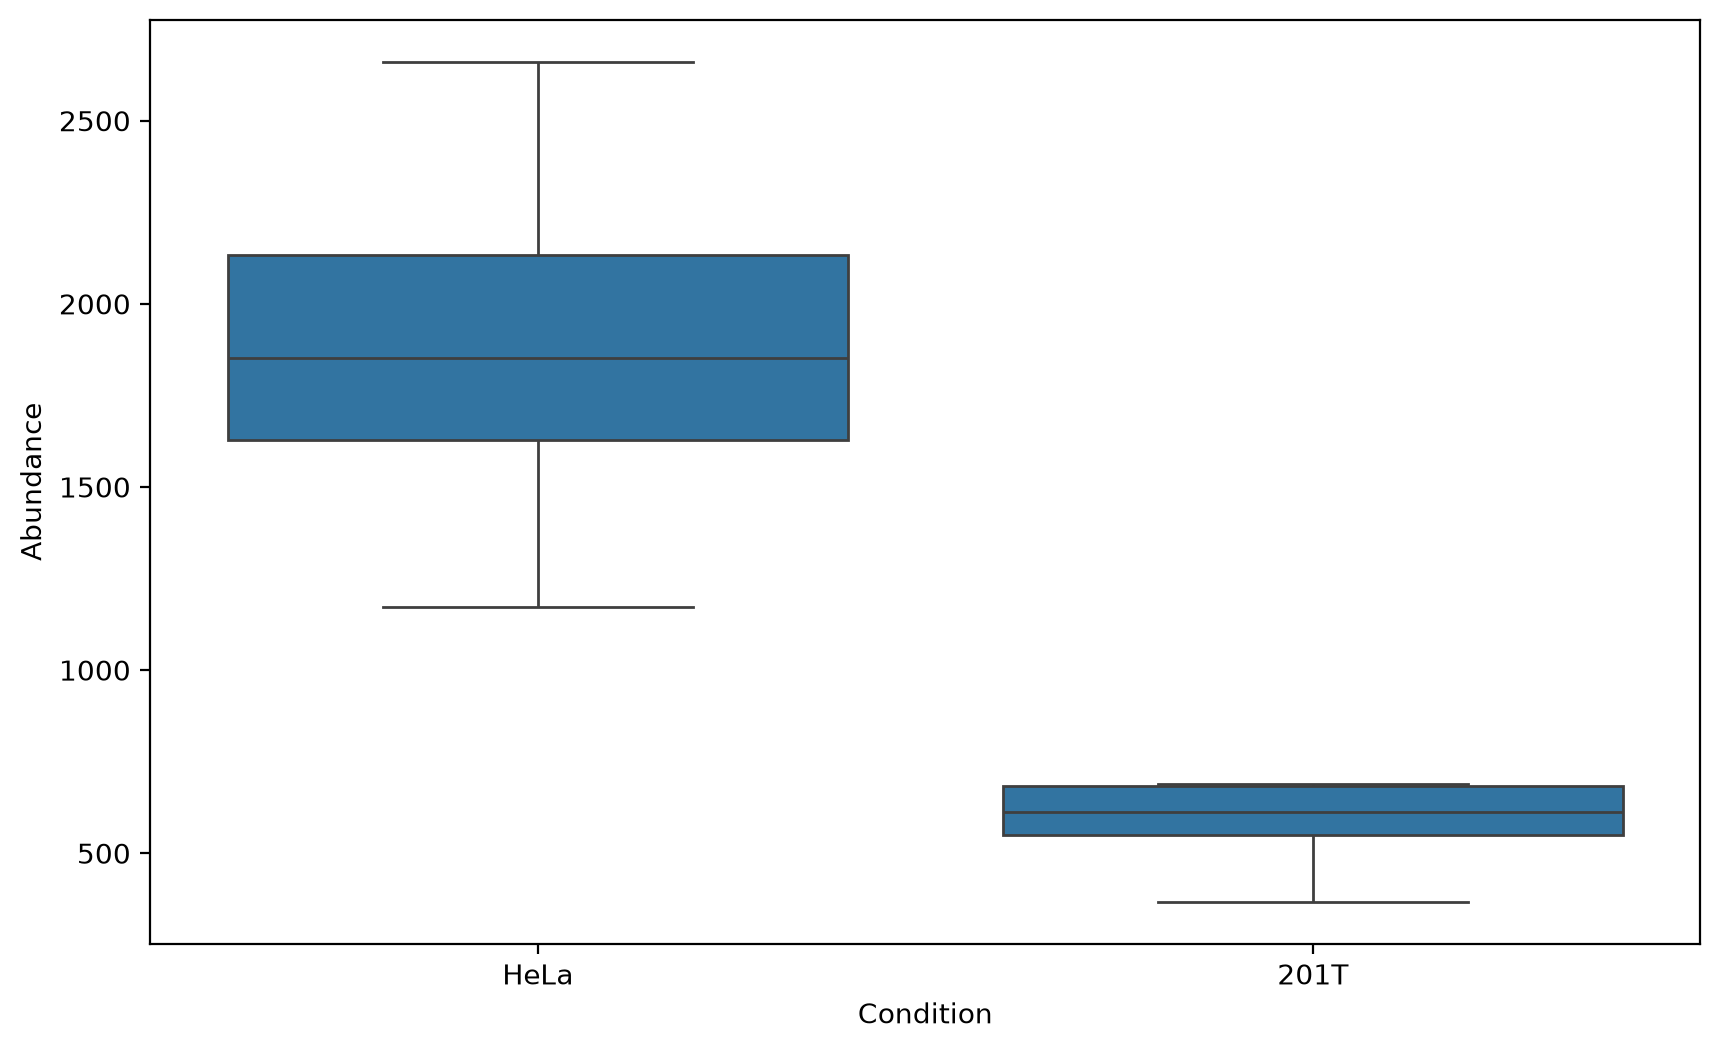

In [58]:
# Filter by TP53_H using prrot_abun
tp53_h = prot_abund[prot_abund['ProteinName'] == 'TP53B_HUMAN']

# Plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=tp53_h, x='Condition', y='Abundance')
plt.show()

## BQ2. 
**Plot the abundance of the most differentiated protein**

In [ ]:
# # Boxplot

## BQ3.
**What are the advantages and disadvantages of MS Proteomics?**